In [1]:
import os, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models, transforms
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize

In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')

Device  : cuda


In [3]:
# ── Reproducibility seed ─────────────────────────────────────────────────────
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
!cp "/content/drive/MyDrive/Deeplense/CT/dataset.zip" "/content/dataset.zip"

In [7]:
!unzip -q /content/dataset.zip -d /content/dataset_extracted

In [8]:
EXTRACT_DIR = '/content/dataset_extracted'

# ── Locate the actual dataset root (handles nested zip structure) ────────────
DATA_ROOT = Path(EXTRACT_DIR) / 'dataset'
assert DATA_ROOT.exists(), f'Expected dataset folder at {DATA_ROOT}'
print(f'Dataset root: {DATA_ROOT}')

Dataset root: /content/dataset_extracted/dataset


In [9]:
# ── Count all .npy files across train + val ──────────────────────────────────
CLASS_NAMES = ['no', 'sphere', 'vort']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

all_paths, all_labels = [], []

for split in ['train', 'val']:
    for cls in CLASS_NAMES:
        folder = DATA_ROOT / split / cls
        files = sorted(folder.glob('*.npy'))
        print(f'  {split}/{cls}: {len(files)} files')
        all_paths.extend(files)
        all_labels.extend([CLASS_TO_IDX[cls]] * len(files))

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels)
print(f'\nTotal samples : {len(all_paths)}')
print(f'Class balance : { {c: int((all_labels==i).sum()) for c,i in CLASS_TO_IDX.items()} }')

  train/no: 10000 files
  train/sphere: 10000 files
  train/vort: 10000 files
  val/no: 2500 files
  val/sphere: 2500 files
  val/vort: 2500 files

Total samples : 37500
Class balance : {'no': 12500, 'sphere': 12500, 'vort': 12500}


In [10]:
# ── Inspect a single sample ──────────────────────────────────────────────────
sample = np.load(all_paths[0])
print(f'Shape : {sample.shape}')
print(f'Dtype : {sample.dtype}')
print(f'Min   : {sample.min():.4f}  Max: {sample.max():.4f}')
print(f'Mean  : {sample.mean():.4f}  Std: {sample.std():.4f}')

Shape : (1, 150, 150)
Dtype : float64
Min   : 0.0000  Max: 1.0000
Mean  : 0.0635  Std: 0.1024


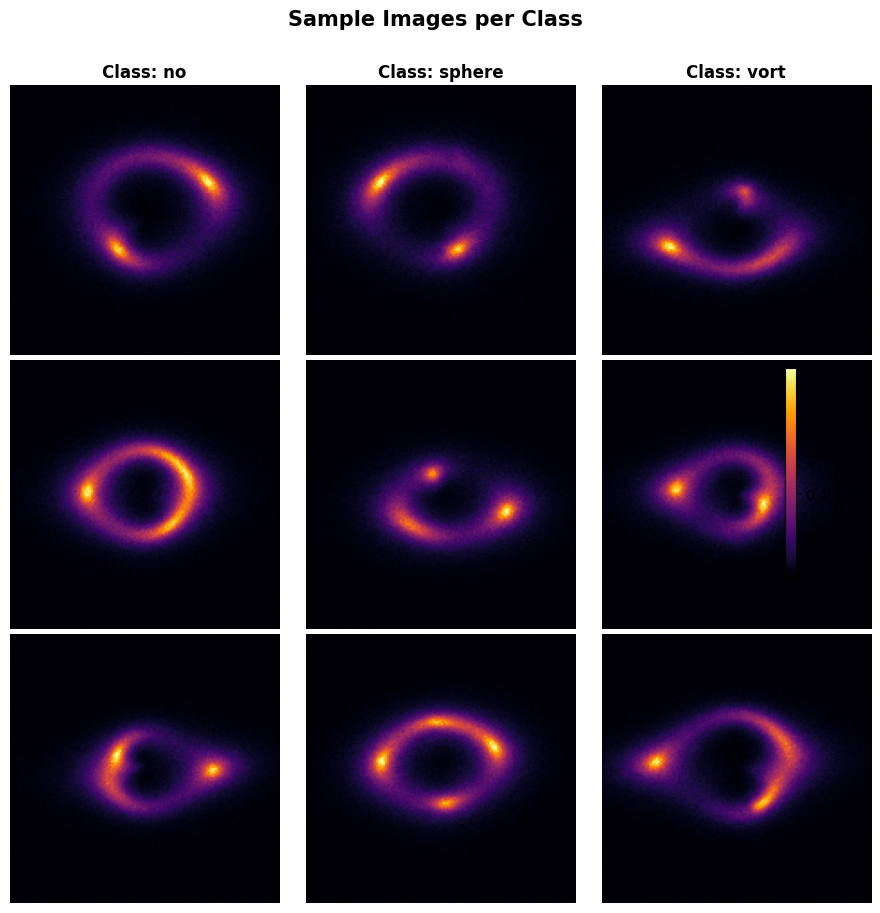

In [11]:
# ── Visual gallery — 3 samples per class ────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
fig.suptitle('Sample Images per Class', fontsize=15, fontweight='bold', y=1.01)

for col, cls in enumerate(CLASS_NAMES):
    idxs = np.where(all_labels == CLASS_TO_IDX[cls])[0][:3]
    for row, idx in enumerate(idxs):
        img = np.load(all_paths[idx]).squeeze()   # (150, 150)
        ax = axes[row][col]
        im = ax.imshow(img, cmap='inferno', vmin=0, vmax=1)
        if row == 0:
            ax.set_title(f'Class: {cls}', fontsize=12, fontweight='bold')
        ax.axis('off')

plt.colorbar(im, ax=axes, fraction=0.015, pad=0.04, label='Pixel Intensity')
plt.tight_layout()
plt.savefig('/content/sample_gallery.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ── Stratified 90 / 10 split across ALL data (train + val combined) ──────────
train_paths, test_paths, train_labels, test_labels = train_test_split(
    all_paths, all_labels,
    test_size=0.10,
    stratify=all_labels,
    random_state=SEED
)

print(f'Train : {len(train_paths)}')
print(f'Test  : {len(test_paths)}')

print()
for cls, idx in CLASS_TO_IDX.items():
    n_tr = (train_labels == idx).sum()
    n_te = (test_labels  == idx).sum()
    print(f'  {cls:8s}  train={n_tr} test={n_te}')

Train : 33750
Test  : 3750

  no        train=11250 test=1250
  sphere    train=11250 test=1250
  vort      train=11250 test=1250


In [13]:
# ── Compute per-dataset statistics for standardisation ───────────────────────
print('Computing dataset mean & std on training set (sample of 500)...')
sample_idx = np.random.choice(len(train_paths), size=min(500, len(train_paths)), replace=False)
sample_pixels = np.concatenate([np.load(train_paths[i]).flatten() for i in sample_idx])
DATASET_MEAN = float(sample_pixels.mean())
DATASET_STD  = float(sample_pixels.std())
print(f'Mean : {DATASET_MEAN:.5f}')
print(f'Std  : {DATASET_STD:.5f}')

Computing dataset mean & std on training set (sample of 500)...
Mean : 0.06201
Std  : 0.11776


In [14]:
class LensDataset(Dataset):
    """Gravitational lens dataset loader for .npy images.

    Args:
        paths  (array-like): File paths to .npy arrays of shape (1, 150, 150).
        labels (array-like): Integer class labels.
        transform           : torchvision transform pipeline.
    """
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = np.load(self.paths[idx]).astype(np.float32)  # (1, 150, 150)
        img = torch.from_numpy(img)                         # FloatTensor
        if self.transform:
            img = self.transform(img)
        return img, int(self.labels[idx])

In [15]:
class AddGaussianNoise:
    """Additive Gaussian noise augmentation."""
    def __init__(self, sigma=0.01):
        self.sigma = sigma
    def __call__(self, tensor):
        return tensor + torch.randn_like(tensor) * self.sigma

In [16]:
NORM = transforms.Normalize(mean=[DATASET_MEAN], std=[DATASET_STD])

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=180),          # full rotation symmetry
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    AddGaussianNoise(sigma=0.005),
    NORM,
])

test_transform = transforms.Compose([NORM])

In [17]:
# ── DataLoaders ──────────────────────────────────────────────────────────────
BATCH_SIZE = 64   # fits comfortably in T4 16 GB VRAM
NUM_WORKERS = 2

train_ds = LensDataset(train_paths, train_labels, transform=train_transform)
test_ds  = LensDataset(test_paths,  test_labels,  transform=test_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Test  batches : {len(test_loader)}')

# Sanity check shapes
x_batch, y_batch = next(iter(train_loader))
print(f'Batch shape   : {x_batch.shape}  |  Labels: {y_batch[:8].tolist()}')

Train batches : 528
Test  batches : 59
Batch shape   : torch.Size([64, 1, 150, 150])  |  Labels: [1, 2, 2, 2, 1, 0, 0, 0]


In [18]:
def build_resnet18_1ch(num_classes: int = 3) -> nn.Module:
    """
    ResNet-18 adapted for single-channel (grayscale) 150×150 input.

    Changes vs. stock torchvision ResNet-18:
      - conv1: in_channels 3 → 1
      - conv1: kernel 7×7 stride-2 → 5×5 stride-1  (preserves spatial info for 150px input)
      - maxpool: removed  (avoids aggressive downsampling on small images)
      - fc: 512 → num_classes
    """
    model = timm.create_model(
        'resnet18',
        pretrained=True,      # train from scratch
        in_chans=1,            # single-channel input
        num_classes=num_classes
    )

    # All layers are trainable by default in timm — confirm explicitly
    for param in model.parameters():
        param.requires_grad = True

    # Optional: add dropout before classifier head
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes)
    )

    return model

In [19]:
model = build_resnet18_1ch(num_classes=3).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total_params:,}')
print(f'Trainable params : {trainable_params:,}')

# Quick forward-pass smoke test
with torch.no_grad():
    dummy = torch.randn(4, 1, 150, 150).to(DEVICE)
    out   = model(dummy)
print(f'Output shape     : {out.shape}')   # (4, 3)

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Total params     : 11,171,779
Trainable params : 11,171,779
Output shape     : torch.Size([4, 3])


In [20]:
NUM_EPOCHS   = 15
LR_MAX       = 3e-3
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = AdamW(model.parameters(), lr=LR_MAX, weight_decay=WEIGHT_DECAY)
steps_per_epoch = len(train_loader)
scheduler = OneCycleLR(
    optimizer,
    max_lr=LR_MAX,
    steps_per_epoch=steps_per_epoch,
    epochs=NUM_EPOCHS,
    pct_start=0.3,
    anneal_strategy='cos'
)

print(f'Epochs          : {NUM_EPOCHS}')
print(f'Max LR          : {LR_MAX}')
print(f'Optimizer       : AdamW  weight_decay={WEIGHT_DECAY}')
print(f'Scheduler       : OneCycleLR (cosine)')
print(f'Loss            : CrossEntropy  label_smoothing=0.05')

Epochs          : 15
Max LR          : 0.003
Optimizer       : AdamW  weight_decay=0.0001
Scheduler       : OneCycleLR (cosine)
Loss            : CrossEntropy  label_smoothing=0.05


In [21]:
def run_epoch(model, loader, criterion, optimizer=None, scheduler=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total      = 0
    epoch_probs = []
    epoch_labels = []

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss   = criterion(logits, y)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=3.0)
                optimizer.step()
                if scheduler._step_count < scheduler.total_steps:
                    scheduler.step()

            total_loss  += loss.item() * x.size(0)
            total       += x.size(0)
            epoch_probs.append(torch.softmax(logits, dim=1).detach().cpu().numpy())
            epoch_labels.append(y.cpu().numpy())

    epoch_probs  = np.concatenate(epoch_probs)
    epoch_labels = np.concatenate(epoch_labels)
    y_bin        = label_binarize(epoch_labels, classes=[0, 1, 2])
    epoch_auc    = roc_auc_score(y_bin, epoch_probs, average='macro', multi_class='ovr')

    return total_loss / total, epoch_auc

In [22]:
# ── Main training loop ────────────────────────────────────────────────────────
history = {'train_loss': [], 'train_auc': []}
CKPT_PATH = '/content/last_model.pth'

print(f'Training on {DEVICE}  |  {NUM_EPOCHS} epochs\n')
print(f'{"Epoch":>5}  {"Train Loss":>11}  {"Train AUC":>9}  {"LR":>10}')
print('─' * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_auc = run_epoch(model, train_loader, criterion, optimizer, scheduler)

    history['train_loss'].append(tr_loss)
    history['train_auc'].append(tr_auc)

    lr = scheduler.get_last_lr()[0]

    torch.save(model.state_dict(), CKPT_PATH)

    print(f'{epoch:4d}  {tr_loss:11.4f}  {tr_auc:8.4f}  {lr:10.2e}')

print(f'   Checkpoint saved to      : {CKPT_PATH}')

Training on cuda  |  15 epochs

Epoch   Train Loss  Train AUC          LR
─────────────────────────────────────────────────────────────────
   1       1.1021    0.5065    4.57e-04
   2       1.0172    0.6599    1.31e-03
   3       0.7609    0.8512    2.28e-03
   4       0.6396    0.9056    2.91e-03
   5       0.5832    0.9257    2.98e-03
   6       0.5324    0.9421    2.85e-03
   7       0.5003    0.9509    2.60e-03
   8       0.4732    0.9579    2.25e-03
   9       0.4526    0.9632    1.83e-03
  10       0.4220    0.9696    1.39e-03
  11       0.4012    0.9742    9.51e-04
  12       0.3765    0.9785    5.64e-04
  13       0.3630    0.9813    2.60e-04
  14       0.3493    0.9831    6.64e-05
  15       0.3447    0.9840    1.20e-08
   Checkpoint saved to      : /content/last_model.pth


In [23]:
# ── Load best checkpoint ──────────────────────────────────────────────────────
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()
print('Best model loaded.')

# ── Collect predictions & probabilities ──────────────────────────────────────
all_probs  = []   # softmax probabilities  (N, 3)
all_preds  = []   # argmax predictions     (N,)
all_true   = []   # ground-truth labels    (N,)

with torch.no_grad():
    for x, y in tqdm(test_loader, desc='Evaluating'):
        x = x.to(DEVICE)
        logits = model(x)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        preds  = logits.argmax(1).cpu().numpy()

        all_probs.append(probs)
        all_preds.append(preds)
        all_true.append(y.numpy())

all_probs = np.concatenate(all_probs, axis=0)   # (N, 3)
all_preds = np.concatenate(all_preds, axis=0)   # (N,)
all_true  = np.concatenate(all_true,  axis=0)   # (N,)

print(f'\nEvaluation complete  —  {len(all_true)} test samples')

Best model loaded.


Evaluating:   0%|          | 0/59 [00:00<?, ?it/s]


Evaluation complete  —  3750 test samples


In [24]:
print('Classification Report\n' + '='*50)
print(classification_report(all_true, all_preds, target_names=CLASS_NAMES, digits=4))

Classification Report
              precision    recall  f1-score   support

          no     0.8486    1.0000    0.9181      1250
      sphere     0.9876    0.8312    0.9027      1250
        vort     0.9494    0.9304    0.9398      1250

    accuracy                         0.9205      3750
   macro avg     0.9285    0.9205    0.9202      3750
weighted avg     0.9285    0.9205    0.9202      3750



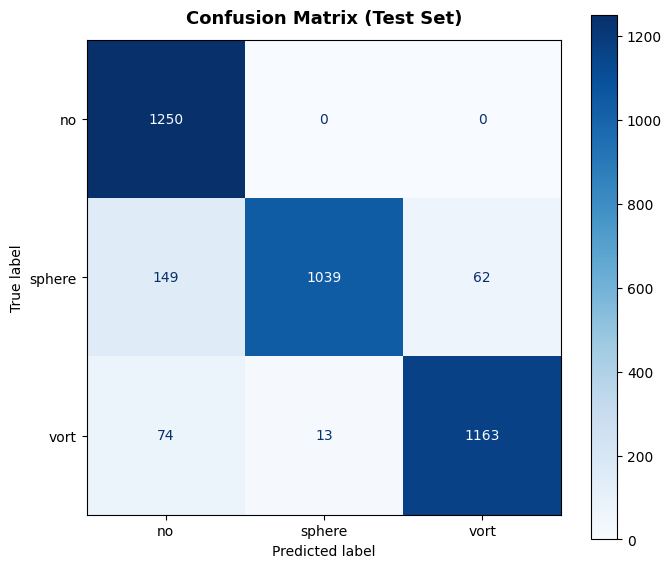


Per-class accuracy:
  no      : 1.0000  (1250/1250)
  sphere  : 0.8312  (1039/1250)
  vort    : 0.9304  (1163/1250)


In [25]:
cm = confusion_matrix(all_true, all_preds)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('Confusion Matrix (Test Set)', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class accuracy
print('\nPer-class accuracy:')
for i, cls in enumerate(CLASS_NAMES):
    acc = cm[i, i] / cm[i].sum()
    print(f'  {cls:8s}: {acc:.4f}  ({cm[i,i]}/{cm[i].sum()})')

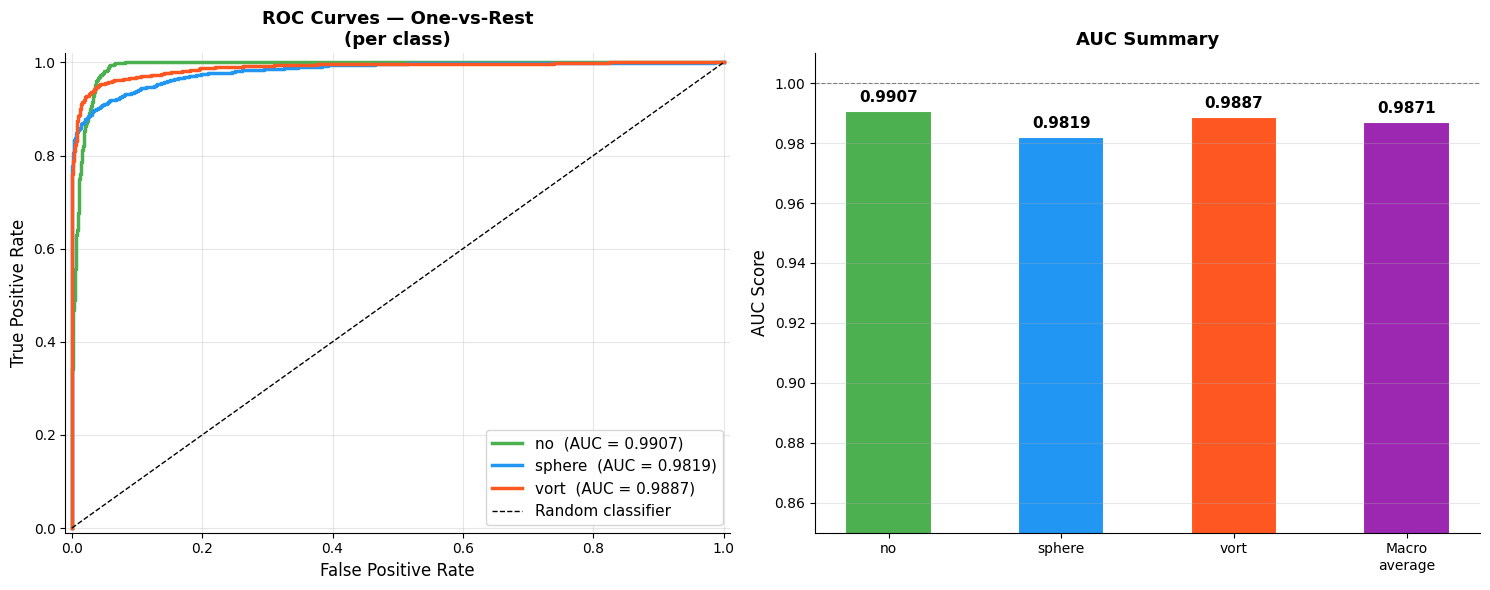


     AUC Scores (One-vs-Rest)
  no      : 0.990661
  sphere  : 0.981911
  vort    : 0.988742
  Macro   : 0.987105


In [26]:
from sklearn.preprocessing import label_binarize

# Binarise labels for one-vs-rest ROC
y_bin = label_binarize(all_true, classes=[0, 1, 2])   # (N, 3)

# ── Per-class ROC + AUC ───────────────────────────────────────────────────────
fpr, tpr, roc_auc = {}, {}, {}
for i, cls in enumerate(CLASS_NAMES):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc[i]        = auc(fpr[i], tpr[i])

# Macro-average AUC
macro_auc = roc_auc_score(y_bin, all_probs, average='macro', multi_class='ovr')

# ── Plot ──────────────────────────────────────────────────────────────────────
palette = {'no': '#4CAF50', 'sphere': '#2196F3', 'vort': '#FF5722'}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: individual ROC curves
ax = axes[0]
for i, cls in enumerate(CLASS_NAMES):
    ax.plot(fpr[i], tpr[i],
            color=palette[cls], linewidth=2.5,
            label=f'{cls}  (AUC = {roc_auc[i]:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.set_xlim([-0.01, 1.01]); ax.set_ylim([-0.01, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curves — One-vs-Rest\n(per class)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
ax.spines[['top','right']].set_visible(False)

# Right: AUC bar chart
ax2 = axes[1]
classes_ext = CLASS_NAMES + ['Macro\naverage']
aucs_ext    = [roc_auc[i] for i in range(3)] + [macro_auc]
colors_ext  = [palette[c] for c in CLASS_NAMES] + ['#9C27B0']
bars = ax2.bar(classes_ext, aucs_ext, color=colors_ext, edgecolor='white',
               linewidth=1.5, width=0.5)
ax2.set_ylim([0.85, 1.01])
ax2.set_ylabel('AUC Score', fontsize=12)
ax2.set_title('AUC Summary', fontsize=13, fontweight='bold')
ax2.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
ax2.spines[['top','right']].set_visible(False)
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, aucs_ext):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print summary ─────────────────────────────────────────────────────────────
print('\n' + '='*40)
print('     AUC Scores (One-vs-Rest)')
print('='*40)
for i, cls in enumerate(CLASS_NAMES):
    print(f'  {cls:8s}: {roc_auc[i]:.6f}')
print(f'  {"Macro":8s}: {macro_auc:.6f}')
print('='*40)

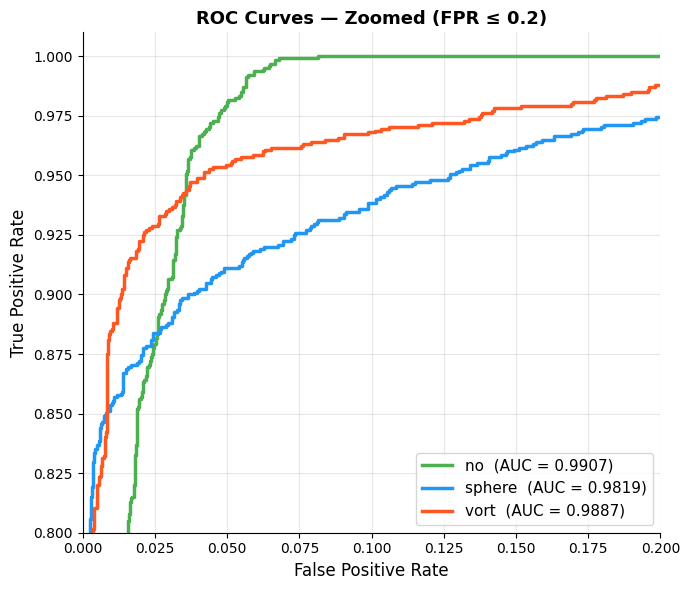

In [27]:
# Zoom into the top-left corner (low FPR region) — important for rare event detection
fig, ax = plt.subplots(figsize=(7, 6))

for i, cls in enumerate(CLASS_NAMES):
    ax.plot(fpr[i], tpr[i], color=palette[cls], linewidth=2.5,
            label=f'{cls}  (AUC = {roc_auc[i]:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlim([0, 0.20]); ax.set_ylim([0.80, 1.01])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curves — Zoomed (FPR ≤ 0.2)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('/content/roc_curves_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
SAVE_DIR = '/content/drive/MyDrive/Deeplense/CT/outputs/resnet18'
os.makedirs(SAVE_DIR, exist_ok=True)

# Model weights
!cp /content/last_model.pth "{SAVE_DIR}/last_model.pth"

# Figures
for fig_name in ['sample_gallery', 'pixel_distributions', 'learning_curves',
                 'confusion_matrix', 'roc_curves', 'roc_curves_zoomed', 'gradcam']:
    src = f'/content/{fig_name}.png'
    if os.path.exists(src):
        !cp "{src}" "{SAVE_DIR}/{fig_name}.png"

print(f'All outputs saved to {SAVE_DIR}')

All outputs saved to /content/drive/MyDrive/Deeplense/CT/outputs/resnet18


In [29]:
from sklearn.metrics import accuracy_score, f1_score

test_acc = accuracy_score(all_true, all_preds)
f1_macro = f1_score(all_true, all_preds, average='macro')

print('╔══════════════════════════════════════════╗')
print('║        FINAL EVALUATION RESULTS          ║')
print('╠══════════════════════════════════════════╣')
print(f'║  Test Accuracy      : {test_acc:.4f}             ║')
print(f'║  F1 Score (macro)   : {f1_macro:.4f}             ║')
print('╠══════════════════════════════════════════╣')
print('║  AUC Scores (One-vs-Rest)                ║')
for i, cls in enumerate(CLASS_NAMES):
    print(f'║    {cls:8s}         : {roc_auc[i]:.4f}             ║')
print(f'║    Macro avg        : {macro_auc:.4f}             ║')
print('╚══════════════════════════════════════════╝')

╔══════════════════════════════════════════╗
║        FINAL EVALUATION RESULTS          ║
╠══════════════════════════════════════════╣
║  Test Accuracy      : 0.9205             ║
║  F1 Score (macro)   : 0.9202             ║
╠══════════════════════════════════════════╣
║  AUC Scores (One-vs-Rest)                ║
║    no               : 0.9907             ║
║    sphere           : 0.9819             ║
║    vort             : 0.9887             ║
║    Macro avg        : 0.9871             ║
╚══════════════════════════════════════════╝
